# Go/NoGo MRCP Classification — new sessions

Works with any recording from `gng_task.py` (with or without self-paced block).
Only the **Config** cell needs editing between sessions.

In [14]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mne.filter import filter_data
from scipy.signal import welch
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

## Config

**Edit these three lines between sessions.**

In [15]:
SUBJECT = "W"   # merged dataset: V + X + Z
SUBJECTS = [
    ("V", "20260617"),
    ("X", "20260618"),
    ("Z", "20260618"),
]

# ── fixed params (don't change) ───────────────────────────────────────────────
FS            = 250.0
EPOCH_S       = 1.5
N_EPOCH       = int(EPOCH_S * FS)
PRE_S         = 0.2
N_PRE         = int(PRE_S * FS)          # 50 samples pre-cue
LATE_MS       = 200;   N_LATE       = int(LATE_MS / 1000 * FS)
LATE_SLOPE_MS = 500;   N_LATE_SLOPE = int(LATE_SLOPE_MS / 1000 * FS)
N_SEGS        = 6

ALL_COLS      = [f"ch{i}" for i in range(16)]
CENTRAL_IDX   = range(16)
CENTRAL_NAMES = list(range(16))
N_CH          = len(list(CENTRAL_IDX))
SEED          = 42

print(f"SUBJECT={SUBJECT}  merging {[s for s,d in SUBJECTS]}")


SUBJECT=W  merging ['V', 'X', 'Z']


## Load sessions

In [16]:
sessions = {}
for subj, date in SUBJECTS:
    root = f"../data/subject{subj}"
    subj_files = sorted(f for f in os.listdir(root)
                        if f.startswith(f"{subj}_eeg_{date}_") and f.endswith(".csv"))
    print(f"Subject {subj} ({date}): {len(subj_files)} session(s)")
    for fname in subj_files:
        stamp_raw = fname.split("_")[-1][:-4]   # e.g. '150226'
        key       = f"{subj}_{stamp_raw}"        # unique across subjects

        eeg_df = pd.read_csv(f"{root}/{fname}")
        mrk_df = pd.read_csv(f"{root}/{subj}_markers_{date}_{stamp_raw}.csv")

        raw_ts  = eeg_df["lsl_timestamp"].values
        raw_eeg = eeg_df[ALL_COLS].values.astype(np.float64)

        # ── Timestamp alignment ─────────────────────────────────────────
        btn_ch    = eeg_df.iloc[:, -1].values.astype(bool)
        raw_edges = raw_ts[np.where(np.diff(btn_ch.astype(int)) > 0)[0] + 1]
        kept = []
        for t in raw_edges:
            if not kept or t - kept[-1] > 0.5:
                kept.append(t)
        deb_edges    = np.array(kept)
        press_mrk_ts = mrk_df.loc[
            mrk_df["marker_label"] == "button_press", "lsl_timestamp"
        ].values
        n_pair    = min(len(deb_edges), len(press_mrk_ts))
        ts_offset = float(np.median(deb_edges[:n_pair] - press_mrk_ts[:n_pair])) if n_pair else 0.0
        mrk_df["lsl_timestamp"] += ts_offset

        filt = filter_data(raw_eeg.T, FS, 0.5, 4.0, verbose=False).T
        filt -= filt.mean(axis=1, keepdims=True)              # CAR
        eeg_c = filt[:, list(CENTRAL_IDX)].astype(np.float32)

        sessions[key] = (raw_ts, eeg_c, mrk_df)
        n_go   = (mrk_df.marker_code == 10).sum()
        n_nogo = (mrk_df.marker_code == 20).sum()
        print(f"  {key}: offset={ts_offset:.1f}s  {len(eeg_c):,} samples  "
              f"GO={n_go}  NOGO={n_nogo}")

stamps = list(sessions.keys())
print(f"\nTotal sessions: {len(stamps)}")


Subject V (20260617): 6 session(s)
  V_150226: offset=1.6s  87,304 samples  GO=75  NOGO=25
  V_163354: offset=1.0s  67,584 samples  GO=50  NOGO=50
  V_164144: offset=-0.9s  64,981 samples  GO=50  NOGO=50
  V_164714: offset=1.0s  64,082 samples  GO=50  NOGO=50
  V_165256: offset=1.0s  65,556 samples  GO=50  NOGO=50
  V_165815: offset=1.0s  65,656 samples  GO=50  NOGO=50
Subject X (20260618): 1 session(s)
  X_101323: offset=1781275841.1s  267,752 samples  GO=100  NOGO=100
Subject Z (20260618): 6 session(s)
  Z_125821: offset=1781276233.3s  194,834 samples  GO=100  NOGO=100
  Z_131405: offset=1781276233.3s  193,373 samples  GO=100  NOGO=100
  Z_133154: offset=1781276233.3s  192,279 samples  GO=100  NOGO=100
  Z_140110: offset=1781276233.3s  188,991 samples  GO=100  NOGO=100
  Z_153514: offset=1780742191.8s  190,853 samples  GO=100  NOGO=100
  Z_155418: offset=1780742191.8s  191,897 samples  GO=100  NOGO=100

Total sessions: 13


## Epoch extraction

Both classes are aligned at **cue onset** (t = 0), post-cue window 0 → +1.5 s.  
Positive class: **GO cue** onsets (all GO trials).  
Negative class: **NOGO cue** onsets.  
Self-paced presses have no cue so are extracted pre-press for MRCP visualization only.

In [17]:
def extract_epochs_session(stamp):
    ts, data, mrk = sessions[stamp]

    go_ts   = mrk.loc[mrk.marker_label == "go_onset",   "lsl_timestamp"].values
    nogo_ts = mrk.loc[mrk.marker_label == "nogo_onset",  "lsl_timestamp"].values
    hit_ts  = mrk.loc[mrk.marker_label == "hit",         "lsl_timestamp"].values
    sp_ts   = mrk.loc[mrk.marker_code == 41,             "lsl_timestamp"].values

    rts = [h - go_ts[go_ts < h][-1] for h in hit_ts if len(go_ts[go_ts < h])]
    median_rt = float(np.median(rts)) if rts else 0.8

    epochs, labels, kinds = [], [], []

    # POSITIVE (label=1): 1.5 s pre-press — captures MRCP
    # Window = [press - EPOCH_S - PRE_S,  press]
    # PRE_S = baseline from the quiet period just before the 1.5 s window
    for press_arr, kind in [(hit_ts, "go_hit"), (sp_ts, "sp_press")]:
        for t0 in press_arr:
            idx   = np.searchsorted(ts, t0)
            start = idx - N_EPOCH - N_PRE
            end   = idx
            if start >= 0 and end <= len(data):
                epochs.append(data[start:end])
                labels.append(1)
                kinds.append(kind)

    # NEGATIVE (label=0): 1.5 s post-NOGO cue — no press will happen
    # Window = [nogo_cue - PRE_S,  nogo_cue + EPOCH_S]
    for t0 in nogo_ts:
        idx   = np.searchsorted(ts, t0)
        start = idx - N_PRE
        end   = idx + N_EPOCH
        if start >= 0 and end <= len(data):
            epochs.append(data[start:end])
            labels.append(0)
            kinds.append("nogo_cue")

    return (
        np.array(epochs, dtype=np.float32),
        np.array(labels, dtype=np.int8),
        np.array(kinds),
        median_rt,
    )


all_raw, all_y, all_kinds, all_sid, all_med_rt = [], [], [], [], []
for sid, stamp in enumerate(stamps):
    raw, y, kinds, med_rt = extract_epochs_session(stamp)
    n_pos = (y == 1).sum(); n_neg = (y == 0).sum()
    print(f"  Session {sid} ({stamp}): {n_pos} press  {n_neg} NOGO  "
          f"median_RT={med_rt*1000:.0f} ms")
    all_raw.append(raw); all_y.append(y); all_kinds.append(kinds)
    all_sid.append(np.full(len(y), sid, dtype=np.int32))
    all_med_rt.append(med_rt)

raw_all          = np.concatenate(all_raw)     # (N, N_PRE+N_EPOCH, N_CH)
y_all            = np.concatenate(all_y)
kinds_all        = np.concatenate(all_kinds)
s_all            = np.concatenate(all_sid)
n_sessions       = len(stamps)
median_rt_global = float(np.median(all_med_rt))

press_mask = y_all == 1
nogo_mask  = y_all == 0
print(f"\nTotal: {len(y_all)} epochs  ({press_mask.sum()} press, {nogo_mask.sum()} NOGO)")
print(f"Positive breakdown: {(kinds_all=='go_hit').sum()} GO hits, "
      f"{(kinds_all=='sp_press').sum()} SP presses")
print(f"Epoch shape: {raw_all.shape}")
print(f"Global median RT: {median_rt_global*1000:.0f} ms")


  Session 0 (V_150226): 74 press  25 NOGO  median_RT=499 ms
  Session 1 (V_163354): 49 press  50 NOGO  median_RT=592 ms
  Session 2 (V_164144): 50 press  49 NOGO  median_RT=605 ms
  Session 3 (V_164714): 50 press  50 NOGO  median_RT=474 ms
  Session 4 (V_165256): 49 press  50 NOGO  median_RT=359 ms
  Session 5 (V_165815): 50 press  50 NOGO  median_RT=340 ms
  Session 6 (X_101323): 94 press  88 NOGO  median_RT=361 ms
  Session 7 (Z_125821): 99 press  100 NOGO  median_RT=357 ms
  Session 8 (Z_131405): 100 press  100 NOGO  median_RT=366 ms
  Session 9 (Z_133154): 100 press  100 NOGO  median_RT=360 ms
  Session 10 (Z_140110): 100 press  100 NOGO  median_RT=345 ms
  Session 11 (Z_153514): 100 press  100 NOGO  median_RT=355 ms
  Session 12 (Z_155418): 100 press  100 NOGO  median_RT=379 ms

Total: 1977 epochs  (1015 press, 962 NOGO)
Positive breakdown: 1015 GO hits, 0 SP presses
Epoch shape: (1977, 425, 16)
Global median RT: 361 ms


## Grand-average cue-locked ERP

Aligned at **cue onset** (t = 0), 0 → +1.5 s post-cue.  
Blue = GO trials, red = NOGO trials.  
Dotted vertical = median GO reaction time (where presses cluster).

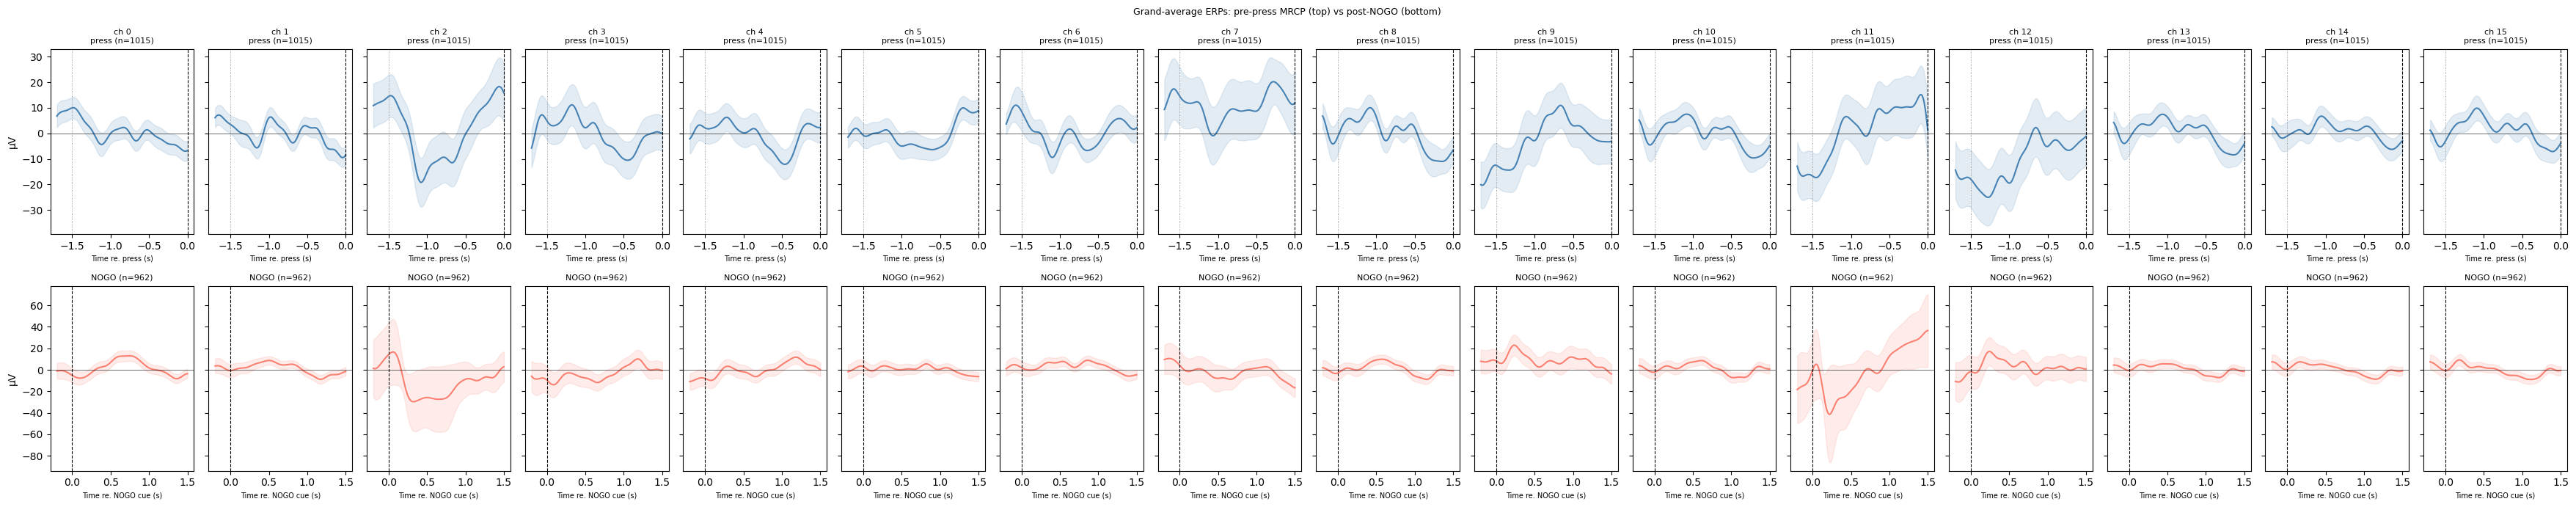

In [18]:
%matplotlib inline

# positive: t=0 at press,     epoch covers [-(EPOCH_S+PRE_S), 0]
t_press = np.linspace(-(EPOCH_S + PRE_S), 0, N_PRE + N_EPOCH)
# negative: t=0 at NOGO cue,  epoch covers [-PRE_S, +EPOCH_S]
t_nogo  = np.linspace(-PRE_S, EPOCH_S, N_PRE + N_EPOCH)

press_ep = raw_all[press_mask]
nogo_ep  = raw_all[nogo_mask]

n_rows = 2
n_cols = N_CH
fig, axes = plt.subplots(n_rows, n_cols, figsize=(max(12, n_cols * 2.2), 7), sharey='row')
if n_cols == 1:
    axes = axes.reshape(n_rows, 1)

for ch in range(N_CH):
    # row 0: MRCP (press-locked)
    ax = axes[0, ch]
    mu = press_ep[:, :, ch].mean(0)
    se = press_ep[:, :, ch].std(0) / np.sqrt(len(press_ep))
    ax.plot(t_press, mu, color='steelblue')
    ax.fill_between(t_press, mu - se, mu + se, alpha=0.15, color='steelblue')
    ax.axvline(0,       color='k',    lw=0.8, ls='--', label='press')
    ax.axvline(-EPOCH_S, color='gray', lw=0.6, ls=':')
    ax.axhline(0,       color='k',    lw=0.4)
    ax.set_title(f'ch {CENTRAL_NAMES[ch]}\npress (n={len(press_ep)})', fontsize=8)
    ax.set_xlabel('Time re. press (s)', fontsize=7)

    # row 1: NOGO ERP (cue-locked)
    ax = axes[1, ch]
    mu = nogo_ep[:, :, ch].mean(0)
    se = nogo_ep[:, :, ch].std(0) / np.sqrt(len(nogo_ep))
    ax.plot(t_nogo, mu, color='salmon')
    ax.fill_between(t_nogo, mu - se, mu + se, alpha=0.15, color='salmon')
    ax.axvline(0, color='k', lw=0.8, ls='--', label='NOGO cue')
    ax.axhline(0, color='k', lw=0.4)
    ax.set_title(f'NOGO (n={len(nogo_ep)})', fontsize=8)
    ax.set_xlabel('Time re. NOGO cue (s)', fontsize=7)

axes[0, 0].set_ylabel('\u00b5V')
axes[1, 0].set_ylabel('\u00b5V')
fig.suptitle('Grand-average ERPs: pre-press MRCP (top) vs post-NOGO (bottom)', fontsize=9)
plt.tight_layout()
plt.show()


## Feature extraction

In [19]:
def epoch_features(epoch):
    T        = epoch.shape[0]
    baseline = epoch[:int(0.1 * FS)].mean(axis=0)
    ep       = epoch - baseline
    t_c      = np.arange(T, dtype=np.float64) - T / 2

    # ── global temporal ──────────────────────────────────────────────────
    feat_mean  = ep.mean(axis=0)                                        # (N_CH,)
    feat_std   = ep.std(axis=0)                                         # (N_CH,)
    feat_slope = (ep * t_c[:, None]).sum(axis=0) / (t_c ** 2).sum()   # (N_CH,)

    # skewness and kurtosis per channel
    mu   = feat_mean
    s    = feat_std + 1e-8
    feat_skew = ((ep - mu) ** 3).mean(axis=0) / s ** 3                 # (N_CH,)
    feat_kurt = ((ep - mu) ** 4).mean(axis=0) / s ** 4 - 3.0          # (N_CH,)

    # ── per-segment shape ────────────────────────────────────────────────
    seg_size = T // N_SEGS
    segs     = [ep[i*seg_size:(i+1)*seg_size] for i in range(N_SEGS)]
    feat_segs_mean = np.stack([s.mean(0) for s in segs]).T.flatten()   # (N_SEGS*N_CH,)
    feat_segs_std  = np.stack([s.std(0)  for s in segs]).T.flatten()   # (N_SEGS*N_CH,)
    feat_segs_min  = np.stack([s.min(0)  for s in segs]).T.flatten()   # (N_SEGS*N_CH,)
    feat_segs_max  = np.stack([s.max(0)  for s in segs]).T.flatten()   # (N_SEGS*N_CH,)

    # ── late window ─────────────────────────────────────────────────────
    feat_late = ep[-N_LATE:].mean(axis=0)                               # (N_CH,)

    ep_ls = ep[-N_LATE_SLOPE:]
    t_ls  = np.arange(N_LATE_SLOPE, dtype=np.float64) - N_LATE_SLOPE / 2
    feat_late_slope = (ep_ls * t_ls[:, None]).sum(axis=0) / (t_ls ** 2).sum()

    # ── spectral ─────────────────────────────────────────────────────────
    _, psd = welch(ep.T, fs=FS, nperseg=min(T, 128))
    freqs  = np.fft.rfftfreq(min(T, 128), 1.0 / FS)
    feat_delta = psd[:, (freqs >= 0.5) & (freqs <= 4.0)].mean(axis=1)  # (N_CH,)

    return np.concatenate([
        feat_mean, feat_std, feat_slope, feat_skew, feat_kurt,
        feat_segs_mean, feat_segs_std, feat_segs_min, feat_segs_max,
        feat_late, feat_late_slope, feat_delta,
    ]).astype(np.float32)


def bc_features(ep):
    baseline = ep[:N_PRE].mean(axis=0)
    return epoch_features(ep[N_PRE:] - baseline)


X_all = np.array([bc_features(ep) for ep in raw_all])
# old: 5*N_CH + N_SEGS*N_CH  new: 5*N_CH + 4*N_SEGS*N_CH + 2*N_CH
n_feat_per_ch = 5 + 4 * N_SEGS + 2  # mean,std,slope,skew,kurt + 4×segs + late,late_slope,delta... wait
print(f"Feature matrix: {X_all.shape}  "
      f"({X_all.shape[1] // N_CH} features/channel)")


Feature matrix: (1977, 512)  (32 features/channel)


In [20]:
# Windowing removed — each epoch produces one feature vector via bc_features.
# X_all, y_all, s_all are used directly in LOSO.


## Leave-one-session-out CV

*(Skipped automatically if only 1 session — shows training metrics instead.)*

In [21]:
_rng = np.random.default_rng(SEED)

def balance(X, y, rng):
    idx0 = np.where(y == 0)[0]; idx1 = np.where(y == 1)[0]
    n    = min(len(idx0), len(idx1))
    idx  = np.concatenate([rng.choice(idx0, n, replace=False),
                           rng.choice(idx1, n, replace=False)])
    return X[np.sort(idx)], y[np.sort(idx)]

def make_clf():
    return make_pipeline(
        StandardScaler(),
        LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
    )

fold_results = []
all_probs    = []
all_true     = []

if n_sessions == 1:
    X_b, y_b = balance(X_all, y_all, _rng)
    clf = make_clf(); clf.fit(X_b, y_b)
    prob = clf.predict_proba(X_all)[:, 1]
    auc  = roc_auc_score(y_all, prob)
    ap   = average_precision_score(y_all, prob)
    fold_results.append(dict(session=0, stamp=stamps[0], auc=auc, ap=ap))
    all_probs.append(prob); all_true.append(y_all)
    print(f"  Single session (train=test):  AUC={auc:.4f}  AP={ap:.4f}  "
          f"[not a generalisation estimate]")
else:
    for test_sid in range(n_sessions):
        tr = s_all != test_sid; te = s_all == test_sid
        X_tr_b, y_tr_b = balance(X_all[tr], y_all[tr], _rng)
        clf = make_clf(); clf.fit(X_tr_b, y_tr_b)
        prob = clf.predict_proba(X_all[te])[:, 1]
        auc  = roc_auc_score(y_all[te], prob)
        ap   = average_precision_score(y_all[te], prob)
        fold_results.append(dict(session=test_sid, stamp=stamps[test_sid],
                                 auc=auc, ap=ap))
        all_probs.append(prob); all_true.append(y_all[te])
        print(f"  Session {test_sid} ({stamps[test_sid]}):  AUC={auc:.4f}  AP={ap:.4f}  "
              f"(train {y_tr_b.sum()} pos + {(y_tr_b==0).sum()} neg)")

    mean_auc = np.mean([r['auc'] for r in fold_results])
    std_auc  = np.std( [r['auc'] for r in fold_results])
    mean_ap  = np.mean([r['ap']  for r in fold_results])
    print(f"\nLOSO  AUC = {mean_auc:.4f} \u00b1{std_auc:.4f}   AP = {mean_ap:.4f}")

all_probs = np.concatenate(all_probs)
all_true  = np.concatenate(all_true)


  Session 0 (V_150226):  AUC=0.6038  AP=0.8054  (train 937 pos + 937 neg)
  Session 1 (V_163354):  AUC=0.5343  AP=0.5367  (train 912 pos + 912 neg)
  Session 2 (V_164144):  AUC=0.5286  AP=0.5395  (train 913 pos + 913 neg)
  Session 3 (V_164714):  AUC=0.5984  AP=0.5847  (train 912 pos + 912 neg)
  Session 4 (V_165256):  AUC=0.5706  AP=0.6141  (train 912 pos + 912 neg)
  Session 5 (V_165815):  AUC=0.6028  AP=0.5938  (train 912 pos + 912 neg)
  Session 6 (X_101323):  AUC=0.4514  AP=0.5082  (train 874 pos + 874 neg)
  Session 7 (Z_125821):  AUC=0.5674  AP=0.5904  (train 862 pos + 862 neg)
  Session 8 (Z_131405):  AUC=0.5040  AP=0.5153  (train 862 pos + 862 neg)
  Session 9 (Z_133154):  AUC=0.4938  AP=0.5117  (train 862 pos + 862 neg)
  Session 10 (Z_140110):  AUC=0.4683  AP=0.4804  (train 862 pos + 862 neg)
  Session 11 (Z_153514):  AUC=0.5582  AP=0.5304  (train 862 pos + 862 neg)
  Session 12 (Z_155418):  AUC=0.5441  AP=0.5508  (train 862 pos + 862 neg)

LOSO  AUC = 0.5404 ±0.0481   AP = 

## Model zoo — LOSO comparison


  LDA-shrinkage           AUC=0.5366 ±0.0458
  LogReg                  AUC=0.5606 ±0.0450
  SVM-RBF                 AUC=0.5415 ±0.0578
  SVM-linear              AUC=0.5591 ±0.0505
  RandomForest            AUC=0.5214 ±0.0724
  GradientBoosting        AUC=0.5327 ±0.0535
  MLP                     AUC=0.5254 ±0.0608
Computing rank from data with rank=None
    Using tolerance 3.4e+03 (2.2e-16 eps * 16 dim * 9.4e+17  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Computing rank from data with rank=None
    Using tolerance 3e+03 (2.2e-16 eps * 16 dim * 8.5e+17  max singular value)
    Estimated rank (data): 16
    data: rank 16 computed from 16 data channels with 0 projectors
Reducing data rank from 16 -> 16
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 cova

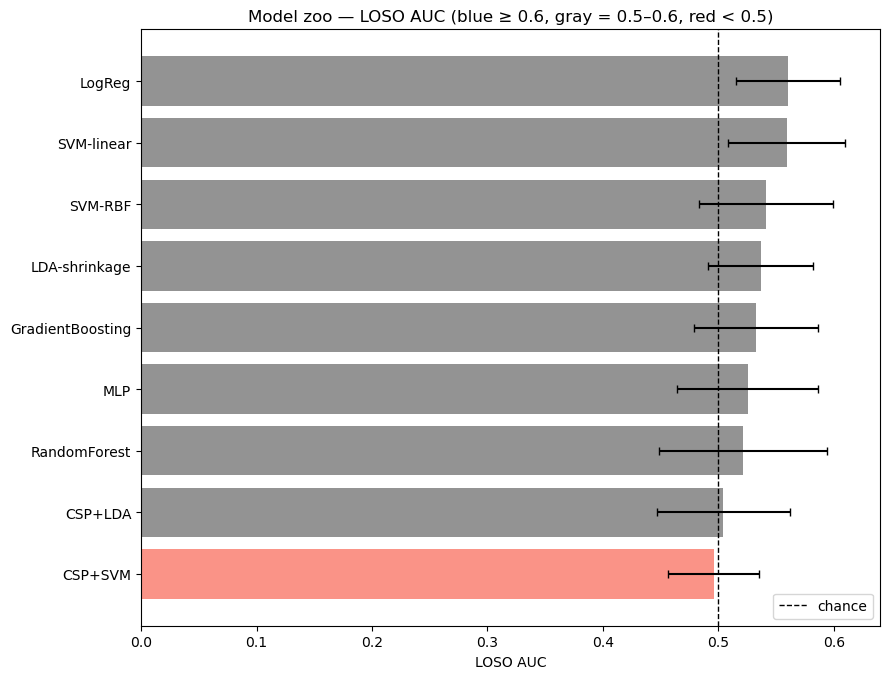

In [22]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.classification import MDM, FgMDM
from pyriemann.tangentspace import TangentSpace

# ── 3-D epoch array (N, N_CH, N_EPOCH) for raw-epoch classifiers ─────────
def bc_epochs_3d(raw):
    out = np.empty((len(raw), N_CH, N_EPOCH), dtype=np.float64)
    for i, ep in enumerate(raw):
        bl = ep[:N_PRE].mean(0)
        out[i] = (ep[N_PRE:] - bl).T
    return out

X_3d = bc_epochs_3d(raw_all)   # (N, N_CH, N_EPOCH)

# ── Model zoo ─────────────────────────────────────────────────────────────
N_CSP = min(6, N_CH)
MODELS = {
    # ── feature-based (use X_all) ──────────────────────────────────────────
    "LDA-shrinkage": (
        "feat",
        make_pipeline(StandardScaler(),
                      LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
    ),
    "LogReg": (
        "feat",
        make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, C=1.0)),
    ),
    "SVM-RBF": (
        "feat",
        make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, C=1.0)),
    ),
    "SVM-linear": (
        "feat",
        make_pipeline(StandardScaler(), SVC(kernel='linear', probability=True, C=0.1)),
    ),
    "RandomForest": (
        "feat",
        RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    ),
    "GradientBoosting": (
        "feat",
        GradientBoostingClassifier(n_estimators=200, max_depth=3, random_state=SEED),
    ),
    "MLP": (
        "feat",
        make_pipeline(StandardScaler(),
                      MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                                    random_state=SEED)),
    ),
    # ── raw-epoch models (use X_3d: N × N_CH × N_EPOCH) ───────────────────
    "CSP+LDA": (
        "raw",
        make_pipeline(
            CSP(n_components=N_CSP, reg='ledoit_wolf', log=True),
            LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
        ),
    ),
    "CSP+SVM": (
        "raw",
        make_pipeline(
            CSP(n_components=N_CSP, reg='ledoit_wolf', log=True),
            SVC(kernel='rbf', probability=True),
        ),
    ),
    "MDM": (
        "raw",
        make_pipeline(Covariances(estimator='ledoit_wolf'),
                      MDM(metric='riemann')),
    ),
    "FgMDM": (
        "raw",
        make_pipeline(Covariances(estimator='ledoit_wolf'),
                      FgMDM(metric='riemann', tsupdate=False)),
    ),
    "TangentSpace+LDA": (
        "raw",
        make_pipeline(
            Covariances(estimator='ledoit_wolf'),
            TangentSpace(metric='riemann'),
            LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto'),
        ),
    ),
}

# ── LOSO loop over all models ──────────────────────────────────────────────
zoo_results = {}
for name, (kind, pipe) in MODELS.items():
    aucs = []
    for test_sid in range(n_sessions):
        tr = s_all != test_sid
        te = s_all == test_sid
        X_tr = X_all[tr]  if kind == 'feat' else X_3d[tr]
        X_te = X_all[te]  if kind == 'feat' else X_3d[te]
        X_b, y_b = balance(X_tr, y_all[tr], _rng)
        try:
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                pipe.fit(X_b, y_b)
                prob = pipe.predict_proba(X_te)[:, 1]
            aucs.append(roc_auc_score(y_all[te], prob))
        except Exception as e:
            aucs.append(np.nan)
    mu, sd = float(np.nanmean(aucs)), float(np.nanstd(aucs))
    zoo_results[name] = (mu, sd)
    print(f"  {name:22s}  AUC={mu:.4f} \u00b1{sd:.4f}")

# ── Bar chart ──────────────────────────────────────────────────────────────
%matplotlib inline
names  = list(zoo_results.keys())
means  = [zoo_results[n][0] for n in names]
stds   = [zoo_results[n][1] for n in names]
order  = np.argsort(means)
colors = ['steelblue' if m >= 0.6 else 'salmon' if m < 0.5 else 'gray'
          for m in [means[i] for i in order]]

fig, ax = plt.subplots(figsize=(9, 0.45 * len(names) + 1.5))
ax.barh([names[i] for i in order], [means[i] for i in order],
        xerr=[stds[i] for i in order], color=colors, alpha=0.85, capsize=3)
ax.axvline(0.5, color='k', lw=1.0, ls='--', label='chance')
ax.set_xlabel('LOSO AUC')
ax.set_title('Model zoo — LOSO AUC (blue ≥ 0.6, gray = 0.5–0.6, red < 0.5)')
ax.legend()
plt.tight_layout()
plt.show()


## Results

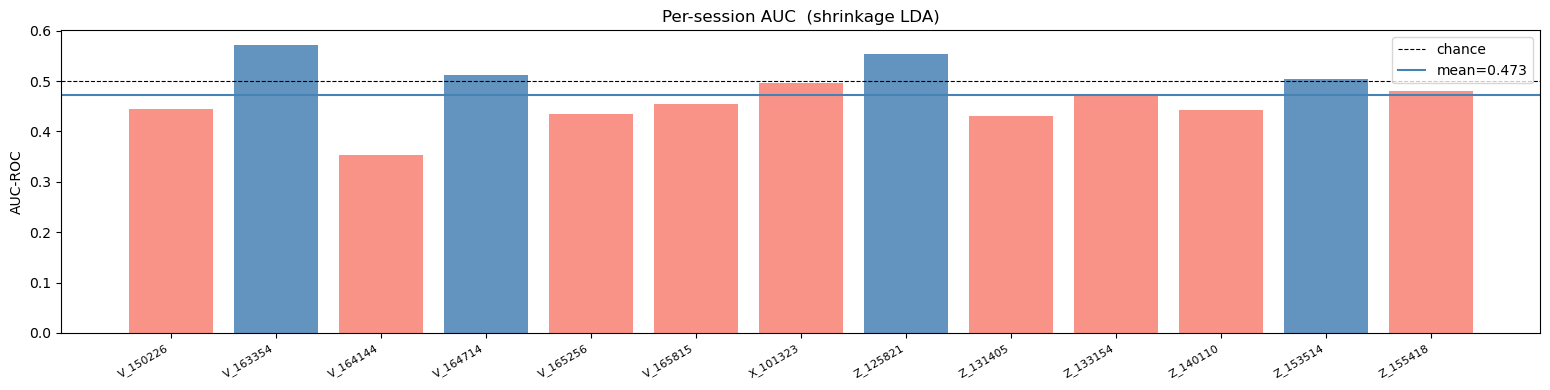

In [61]:
%matplotlib inline

fig, ax = plt.subplots(figsize=(max(6, len(fold_results)*1.2), 4))
sids   = [r["session"] for r in fold_results]
aucs   = [r["auc"]     for r in fold_results]
colors = ["steelblue" if a >= 0.5 else "salmon" for a in aucs]
ax.bar(sids, aucs, color=colors, alpha=0.85)
ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8, label="chance")
if len(fold_results) > 1:
    ax.axhline(mean_auc, color="steelblue", linestyle="-", linewidth=1.5,
               label=f"mean={mean_auc:.3f}")
ax.set_xticks(sids)
ax.set_xticklabels([r["stamp"] for r in fold_results], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("AUC-ROC"); ax.set_title("Per-session AUC  (shrinkage LDA)")
ax.legend(); plt.tight_layout(); plt.show()

## Threshold Calibration

Aggregate ROC from all LOTO/LOSO folds — each epoch scored by the model
that never saw it during training.

Candidate thresholds:
- **Youden's J** — maximises sensitivity + specificity
- **Sens ≥ 0.80 / 0.90** — catch most presses
- **Spec ≥ 0.90 / 0.95** — low false-alarm rate (military priority)


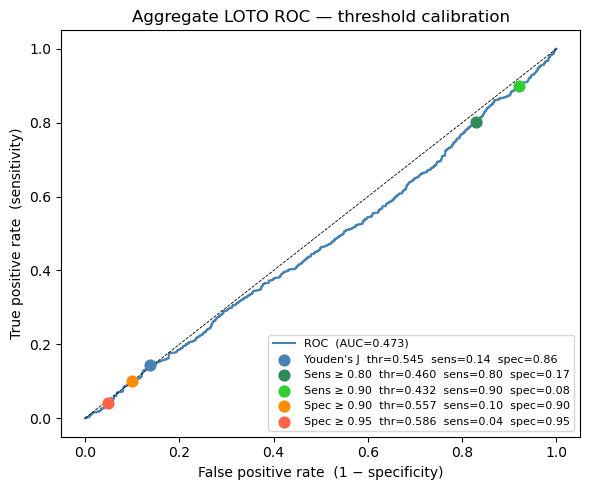

Name            Threshold  Sensitivity  Specificity
----------------------------------------------------
Youden's J          0.545        0.145        0.863
Sens ≥ 0.80         0.460        0.801        0.172
Sens ≥ 0.90         0.432        0.900        0.079
Spec ≥ 0.90         0.557        0.100        0.901
Spec ≥ 0.95         0.586        0.040        0.950


In [62]:
%matplotlib inline
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(all_true, all_probs)
spec = 1 - fpr

# candidate thresholds
j_idx      = np.argmax(tpr + spec - 1)                        # Youden's J
s80_idx    = np.argmax(tpr >= 0.80)                           # sens >= 0.80
s90_idx    = np.argmax(tpr >= 0.90)                           # sens >= 0.90
sp90_idx   = np.where(spec >= 0.90)[0][-1] if (spec >= 0.90).any() else 0
sp95_idx   = np.where(spec >= 0.95)[0][-1] if (spec >= 0.95).any() else 0

candidates = [
    ("Youden's J",   j_idx,    "steelblue"),
    ("Sens ≥ 0.80",  s80_idx,  "seagreen"),
    ("Sens ≥ 0.90",  s90_idx,  "limegreen"),
    ("Spec ≥ 0.90",  sp90_idx, "darkorange"),
    ("Spec ≥ 0.95",  sp95_idx, "tomato"),
]

auc_label = mean_auc if n_sessions > 1 else roc_auc_score(all_true, all_probs)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", linewidth=1.5,
        label=f"ROC  (AUC={auc_label:.3f})")
ax.plot([0, 1], [0, 1], color="k", linewidth=0.6, linestyle="--")

for name, idx, color in candidates:
    ax.scatter(fpr[idx], tpr[idx], s=60, color=color, zorder=5,
               label=f"{name}  thr={thresholds[idx]:.3f}  "
                     f"sens={tpr[idx]:.2f}  spec={spec[idx]:.2f}")

ax.set_xlabel("False positive rate  (1 − specificity)")
ax.set_ylabel("True positive rate  (sensitivity)")
ax.set_title("Aggregate LOTO ROC — threshold calibration")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# summary table
print(f"{'Name':<14} {'Threshold':>10} {'Sensitivity':>12} {'Specificity':>12}")
print("-" * 52)
for name, idx, _ in candidates:
    print(f"{name:<14} {thresholds[idx]:>10.3f} "
          f"{tpr[idx]:>12.3f} {spec[idx]:>12.3f}")

## Live prediction — Youden's J threshold

Slides a `STRIDE`-sample window over the continuous EEG, extracts features,
and plots the classifier output over time.  
Blue verticals = GO presses, green = self-paced presses.  
Red fill = classifier fires above Youden's J threshold.

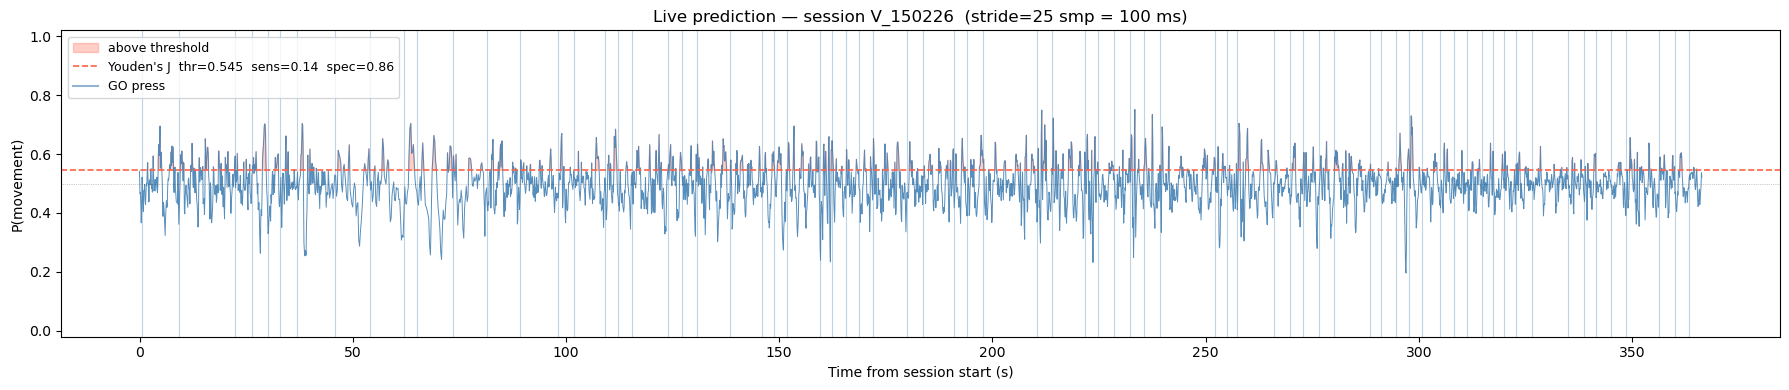

Threshold crossings (rising edges): 307
True GO presses in session: 74   SP presses: 0


In [63]:
%matplotlib inline

# ── Final classifier trained on all data ─────────────────────────────────
# (for LOSO: clf is last fold; retrain here so we always show full-data model)
X_b_viz, y_b_viz = balance(X_all, y_all, _rng)
clf_viz = make_clf()
clf_viz.fit(X_b_viz, y_b_viz)

# ── Session to visualize ─────────────────────────────────────────────────
VIZ_SID = 0        # session index; 0 = first, -1 = last
STRIDE  = 25       # samples between predictions (100 ms @ 250 Hz)

stamp_viz        = stamps[VIZ_SID]
ts_v, data_v, mrk_v = sessions[stamp_viz]
t0 = ts_v[N_EPOCH]

probs_live, t_live = [], []
for i in range(N_EPOCH, len(data_v), STRIDE):
    feat = epoch_features(data_v[i - N_EPOCH:i]).reshape(1, -1)
    probs_live.append(clf_viz.predict_proba(feat)[0, 1])
    t_live.append(ts_v[i] - t0)

probs_live = np.array(probs_live)
t_live     = np.array(t_live)
THR        = thresholds[j_idx]

# ── Marker times relative to session start ───────────────────────────────
go_press_rel = mrk_v.loc[
    (mrk_v.marker_code == 30) & (mrk_v.trial_type == "go"),
    "lsl_timestamp"
].values - t0
sp_press_rel = mrk_v.loc[
    mrk_v.marker_code == 41,
    "lsl_timestamp"
].values - t0

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 4))

ax.plot(t_live, probs_live, color="steelblue", linewidth=0.7, alpha=0.9)
ax.fill_between(t_live, THR, probs_live,
                where=(probs_live >= THR), interpolate=True,
                color="tomato", alpha=0.3, label="above threshold")
ax.axhline(THR, color="tomato", linewidth=1.2, linestyle="--",
           label=f"Youden's J  thr={THR:.3f}  "
                 f"sens={tpr[j_idx]:.2f}  spec={spec[j_idx]:.2f}")
ax.axhline(0.5, color="k", linewidth=0.5, linestyle=":", alpha=0.4)

for t in go_press_rel:
    if 0 <= t <= t_live[-1]:
        ax.axvline(t, color="steelblue", alpha=0.35, linewidth=0.8)
for t in sp_press_rel:
    if 0 <= t <= t_live[-1]:
        ax.axvline(t, color="seagreen", alpha=0.35, linewidth=0.8)

# dummy lines for legend entries
ax.axvline(np.nan, color="steelblue", alpha=0.6, linewidth=1.5, label="GO press")
if len(sp_press_rel) > 0:
    ax.axvline(np.nan, color="seagreen", alpha=0.6, linewidth=1.5, label="SP press")

ax.set_xlabel("Time from session start (s)")
ax.set_ylabel("P(movement)")
ax.set_title(f"Live prediction — session {stamp_viz}  "
             f"(stride={STRIDE} smp = {1000*STRIDE/FS:.0f} ms)")
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Detection summary ────────────────────────────────────────────────────
det_mask = probs_live >= THR
n_detect = int(np.diff(det_mask.astype(int)).clip(0).sum())
n_go     = int((go_press_rel >= 0).sum())
n_sp     = int((sp_press_rel >= 0).sum())
print(f"Threshold crossings (rising edges): {n_detect}")
print(f"True GO presses in session: {n_go}   SP presses: {n_sp}")


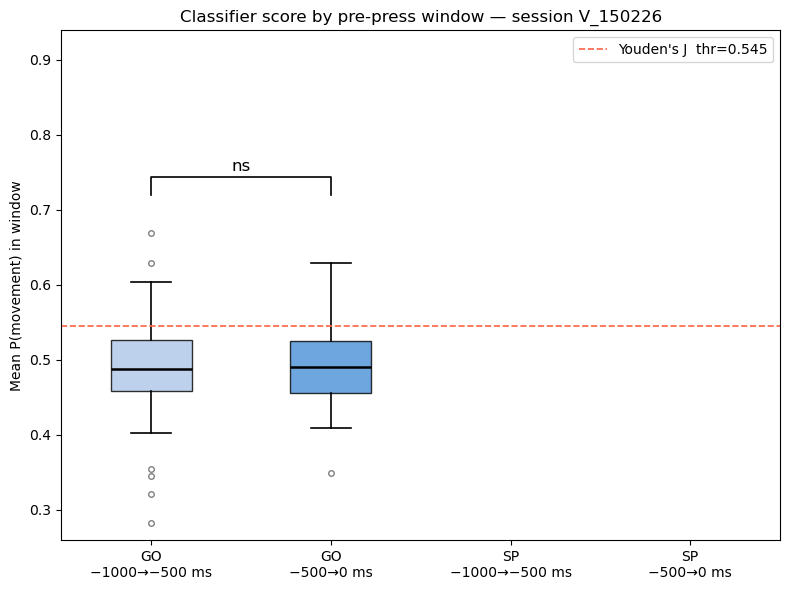

Group                       n    median      mean
------------------------------------------------
GO −1000→−500 ms           74     0.487     0.489
GO −500→0 ms               74     0.490     0.492
SP −1000→−500 ms            0   no data
SP −500→0 ms                0   no data

Pairwise tests
  Wilcoxon (paired)
    GO  early vs late : p=0.8822  ns
  Mann-Whitney U (unpaired)


In [64]:
%matplotlib inline
from scipy.stats import wilcoxon, mannwhitneyu

W1_START, W1_END = -1.000, -0.500  # s
W2_START, W2_END = -0.500,  0.000  # s

def paired_scores(press_times, t_arr, prob_arr):
    """Mean score in each window per press; only includes presses where both windows have data."""
    s1, s2 = [], []
    for tp in press_times:
        m1 = (t_arr >= tp + W1_START) & (t_arr < tp + W1_END)
        m2 = (t_arr >= tp + W2_START) & (t_arr < tp + W2_END)
        if m1.sum() > 0 and m2.sum() > 0:
            s1.append(prob_arr[m1].mean())
            s2.append(prob_arr[m2].mean())
    return np.array(s1), np.array(s2)

GO_W1, GO_W2 = paired_scores(go_press_rel, t_live, probs_live)
SP_W1, SP_W2 = paired_scores(sp_press_rel, t_live, probs_live)

groups = [GO_W1, GO_W2, SP_W1, SP_W2]
labels = ["GO\n−1000→−500 ms", "GO\n−500→0 ms",
          "SP\n−1000→−500 ms", "SP\n−500→0 ms"]
colors = ["#aec6e8", "#4a90d9", "#a8d8b8", "#3aad6a"]

# ── Pairwise tests ────────────────────────────────────────────────────────
def pval_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

# paired Wilcoxon — same trials, early vs late window
_, p_go = wilcoxon(GO_W1, GO_W2)
_, p_sp = wilcoxon(SP_W1, SP_W2) if len(SP_W1) >= 10 else (None, np.nan)

# Mann-Whitney — GO vs SP, same window (unpaired)
_, p_late  = mannwhitneyu(GO_W2, SP_W2, alternative="two-sided") if len(SP_W2) > 0 else (None, np.nan)
_, p_early = mannwhitneyu(GO_W1, SP_W1, alternative="two-sided") if len(SP_W1) > 0 else (None, np.nan)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops=dict(color="k", linewidth=1.8),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker="o", markersize=4, alpha=0.5))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.axhline(THR, color="tomato", linewidth=1.2, linestyle="--",
           label=f"Youden's J  thr={THR:.3f}")
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel("Mean P(movement) in window")
ax.set_title(f"Classifier score by pre-press window — session {stamp_viz}")
ax.legend()

# ── Significance brackets ─────────────────────────────────────────────────
def sig_bracket(ax, x1, x2, y, p, h=0.025, color="k"):
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, color=color)
    ax.text((x1 + x2) / 2, y + h + 0.003, pval_stars(p),
            ha="center", va="bottom", fontsize=12, color=color)

top = max(a.max() for a in groups if len(a)) + 0.05

# GO early vs late  (boxes 1-2, paired Wilcoxon)
sig_bracket(ax, 1, 2, top, p_go)
# SP early vs late  (boxes 3-4, paired Wilcoxon)
if not np.isnan(p_sp):
    sig_bracket(ax, 3, 4, top, p_sp)
# GO late vs SP late  (boxes 2-4, Mann-Whitney U)
if not np.isnan(p_late):
    sig_bracket(ax, 2, 4, top + 0.08, p_late, color="dimgray")
# GO early vs SP early  (boxes 1-3, Mann-Whitney U)
if not np.isnan(p_early):
    sig_bracket(ax, 1, 3, top + 0.08, p_early, color="dimgray")

ax.set_ylim(top=top + 0.22)
plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────
print(f"{'Group':<24} {'n':>4}  {'median':>8}  {'mean':>8}")
print("-" * 48)
for name, arr in zip(labels, groups):
    label = name.replace("\n", " ")
    if len(arr):
        print(f"{label:<24} {len(arr):>4}  {np.median(arr):>8.3f}  {arr.mean():>8.3f}")
    else:
        print(f"{label:<24}    0   no data")

print()
print("Pairwise tests")
print(f"  Wilcoxon (paired)")
print(f"    GO  early vs late : p={p_go:.4f}  {pval_stars(p_go)}")
if not np.isnan(p_sp):
    print(f"    SP  early vs late : p={p_sp:.4f}  {pval_stars(p_sp)}")
print(f"  Mann-Whitney U (unpaired)")
if not np.isnan(p_late):
    print(f"    GO vs SP  (late)  : p={p_late:.4f}  {pval_stars(p_late)}")
if not np.isnan(p_early):
    print(f"    GO vs SP  (early) : p={p_early:.4f}  {pval_stars(p_early)}")

---
## Stimulus-locked classifier: GO vs NOGO

Epoch: −0.2 s → +0.8 s around stimulus onset.  
Positive = GO trial (subject fires), negative = NOGO trial (subject withholds).  
Same features and CV as above — only the epoch window changes.  
Compare AUC with the movement-locked result to see which signal is more exploitable.

In [65]:
STIM_PRE  = 0.2   # s before stimulus onset
STIM_POST = 0.8   # s after  stimulus onset
N_STIM_PRE  = int(STIM_PRE  * FS)
N_STIM_POST = int(STIM_POST * FS)
N_STIM_EPOCH = N_STIM_PRE + N_STIM_POST

def extract_stim_epochs(stamp):
    ts, data, mrk = sessions[stamp]
    go_ts   = mrk.loc[mrk.marker_code == 10, "lsl_timestamp"].values
    nogo_ts = mrk.loc[mrk.marker_code == 20, "lsl_timestamp"].values

    epochs, labels = [], []
    for ts_arr, label in [(go_ts, 1), (nogo_ts, 0)]:
        for t0 in ts_arr:
            idx = np.searchsorted(ts, t0)
            i0  = idx - N_STIM_PRE
            i1  = idx + N_STIM_POST
            if i0 >= 0 and i1 <= len(data):
                epochs.append(data[i0:i1])
                labels.append(label)

    return np.array(epochs, dtype=np.float32), np.array(labels, dtype=np.int8)


stim_raw_list, stim_y_list, stim_sid_list = [], [], []
for sid, stamp in enumerate(stamps):
    raw, y = extract_stim_epochs(stamp)
    print(f"  Session {sid} ({stamp}): {(y==1).sum()} GO  {(y==0).sum()} NOGO")
    stim_raw_list.append(raw)
    stim_y_list.append(y)
    stim_sid_list.append(np.full(len(y), sid, dtype=np.int32))

stim_raw_all = np.concatenate(stim_raw_list)
stim_y_all   = np.concatenate(stim_y_list)
stim_s_all   = np.concatenate(stim_sid_list)
print(f"\nTotal: {len(stim_y_all)} epochs  shape {stim_raw_all.shape}")

X_stim = np.array([epoch_features(e) for e in stim_raw_all])
print(f"Feature matrix: {X_stim.shape}")

  Session 0 (V_150226): 74 GO  25 NOGO
  Session 1 (V_163354): 50 GO  50 NOGO
  Session 2 (V_164144): 50 GO  49 NOGO
  Session 3 (V_164714): 49 GO  50 NOGO
  Session 4 (V_165256): 50 GO  50 NOGO
  Session 5 (V_165815): 50 GO  50 NOGO
  Session 6 (X_101323): 94 GO  88 NOGO
  Session 7 (Z_125821): 99 GO  100 NOGO
  Session 8 (Z_131405): 100 GO  100 NOGO
  Session 9 (Z_133154): 100 GO  100 NOGO
  Session 10 (Z_140110): 100 GO  100 NOGO
  Session 11 (Z_153514): 99 GO  100 NOGO
  Session 12 (Z_155418): 100 GO  100 NOGO

Total: 1977 epochs  shape (1977, 250, 16)
Feature matrix: (1977, 176)


In [66]:
_rng_stim      = np.random.default_rng(SEED)
stim_folds     = []
stim_probs_all = []
stim_true_all  = []

if n_sessions == 1:
    X_b, y_b = balance(X_stim, stim_y_all, _rng_stim)
    clf_stim = make_clf(); clf_stim.fit(X_b, y_b)
    prob = clf_stim.predict_proba(X_stim)[:, 1]
    auc  = roc_auc_score(stim_y_all, prob)
    ap   = average_precision_score(stim_y_all, prob)
    stim_folds.append(dict(session=0, stamp=stamps[0], auc=auc, ap=ap))
    stim_probs_all.append(prob); stim_true_all.append(stim_y_all)
    print(f"  Single session (train=test):  AUC={auc:.4f}  AP={ap:.4f}")
else:
    for test_sid in range(n_sessions):
        tr = stim_s_all != test_sid; te = stim_s_all == test_sid
        X_tr_b, y_tr_b = balance(X_stim[tr], stim_y_all[tr], _rng_stim)
        clf_stim = make_clf(); clf_stim.fit(X_tr_b, y_tr_b)
        prob = clf_stim.predict_proba(X_stim[te])[:, 1]
        auc  = roc_auc_score(stim_y_all[te], prob)
        ap   = average_precision_score(stim_y_all[te], prob)
        stim_folds.append(dict(session=test_sid, stamp=stamps[test_sid], auc=auc, ap=ap))
        stim_probs_all.append(prob); stim_true_all.append(stim_y_all[te])
        print(f"  Session {test_sid} ({stamps[test_sid]}):  AUC={auc:.4f}  AP={ap:.4f}  "
              f"(train {y_tr_b.sum()} pos + {(y_tr_b==0).sum()} neg)")

    stim_mean_auc = np.mean([r['auc'] for r in stim_folds])
    stim_std_auc  = np.std( [r['auc'] for r in stim_folds])
    stim_mean_ap  = np.mean([r['ap']  for r in stim_folds])
    print(f"\nStim-locked LOSO  AUC = {stim_mean_auc:.4f} ±{stim_std_auc:.4f}  "
          f" AP = {stim_mean_ap:.4f}")

stim_probs_all = np.concatenate(stim_probs_all)
stim_true_all  = np.concatenate(stim_true_all)
stim_auc_val   = stim_folds[0]['auc'] if n_sessions == 1 else stim_mean_auc
move_auc_val   = fold_results[0]['auc'] if n_sessions == 1 else mean_auc

  Session 0 (V_150226):  AUC=0.5173  AP=0.7550  (train 937 pos + 937 neg)
  Session 1 (V_163354):  AUC=0.5320  AP=0.5482  (train 912 pos + 912 neg)
  Session 2 (V_164144):  AUC=0.4522  AP=0.4737  (train 913 pos + 913 neg)
  Session 3 (V_164714):  AUC=0.4584  AP=0.4541  (train 912 pos + 912 neg)
  Session 4 (V_165256):  AUC=0.4612  AP=0.5637  (train 912 pos + 912 neg)
  Session 5 (V_165815):  AUC=0.4700  AP=0.4940  (train 912 pos + 912 neg)
  Session 6 (X_101323):  AUC=0.4959  AP=0.5011  (train 874 pos + 874 neg)
  Session 7 (Z_125821):  AUC=0.5481  AP=0.5687  (train 862 pos + 862 neg)
  Session 8 (Z_131405):  AUC=0.4345  AP=0.4568  (train 862 pos + 862 neg)
  Session 9 (Z_133154):  AUC=0.4485  AP=0.5063  (train 862 pos + 862 neg)
  Session 10 (Z_140110):  AUC=0.5998  AP=0.5818  (train 862 pos + 862 neg)
  Session 11 (Z_153514):  AUC=0.5020  AP=0.4753  (train 862 pos + 862 neg)
  Session 12 (Z_155418):  AUC=0.5315  AP=0.5594  (train 862 pos + 862 neg)

Stim-locked LOSO  AUC = 0.4963 ±0.

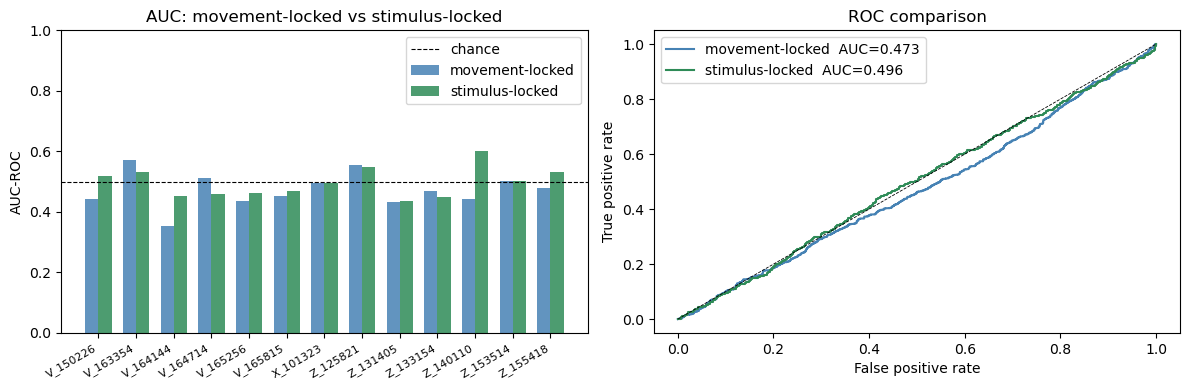

ΔAUC = +0.023  →  stimulus-locked is stronger


In [67]:
%matplotlib inline
from sklearn.metrics import roc_curve as _roc_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Per-session AUC comparison ────────────────────────────────────────────
ax = axes[0]
x = np.arange(len(stamps))
w = 0.35
move_aucs = [r['auc'] for r in fold_results]
stim_aucs = [r['auc'] for r in stim_folds]
ax.bar(x - w/2, move_aucs, width=w, color="steelblue", alpha=0.85, label="movement-locked")
ax.bar(x + w/2, stim_aucs, width=w, color="seagreen",  alpha=0.85, label="stimulus-locked")
ax.axhline(0.5, color="k", linestyle="--", linewidth=0.8, label="chance")
ax.set_xticks(x)
ax.set_xticklabels(stamps, rotation=30, ha="right", fontsize=8)
ax.set_ylabel("AUC-ROC")
ax.set_ylim(0, 1)
ax.set_title("AUC: movement-locked vs stimulus-locked")
ax.legend()

# ── ROC curves ────────────────────────────────────────────────────────────
ax = axes[1]
fpr_m, tpr_m, _ = _roc_curve(all_true,       all_probs)
fpr_s, tpr_s, _ = _roc_curve(stim_true_all,  stim_probs_all)
ax.plot(fpr_m, tpr_m, color="steelblue", linewidth=1.5,
        label=f"movement-locked  AUC={move_auc_val:.3f}")
ax.plot(fpr_s, tpr_s, color="seagreen",  linewidth=1.5,
        label=f"stimulus-locked  AUC={stim_auc_val:.3f}")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.6)
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("ROC comparison")
ax.legend()

plt.tight_layout()
plt.show()

delta = stim_auc_val - move_auc_val
winner = "stimulus-locked" if delta > 0 else "movement-locked"
print(f"ΔAUC = {delta:+.3f}  →  {winner} is stronger")

## Per-channel AUC

Each channel gets its own shrinkage-LDA trained on that channel's 11 features only.
Channels well below chance (AUC < 0.5) have inverted polarity relative to the model's expectation.
The pooled-channel AUC is shown as reference.

In [68]:
%matplotlib inline

def ch_feat_idx(c):
    """Feature-vector slice for channel c in X_all."""
    base_seg  = 2 * N_CH
    base_late = base_seg + N_CH * N_SEGS
    return ([c, N_CH + c]
            + list(range(base_seg + c * N_SEGS, base_seg + (c + 1) * N_SEGS))
            + [base_late + c, base_late + N_CH + c, base_late + 2 * N_CH + c])

_rng_ch = np.random.default_rng(SEED)
ch_aucs = np.zeros(N_CH)

for c in range(N_CH):
    X_c = X_all[:, ch_feat_idx(c)]
    fold_aucs = []
    if n_sessions == 1:
        X_b, y_b = balance(X_c, y_all, _rng_ch)
        clf_c = make_clf(); clf_c.fit(X_b, y_b)
        fold_aucs.append(roc_auc_score(y_all, clf_c.predict_proba(X_c)[:, 1]))
    else:
        for test_sid in range(n_sessions):
            tr = s_all != test_sid; te = s_all == test_sid
            X_tr_b, y_tr_b = balance(X_c[tr], y_all[tr], _rng_ch)
            clf_c = make_clf(); clf_c.fit(X_tr_b, y_tr_b)
            fold_aucs.append(roc_auc_score(y_all[te], clf_c.predict_proba(X_c[te])[:, 1]))
    ch_aucs[c] = np.mean(fold_aucs)
    print(f'  {CENTRAL_NAMES[c]:4s}: AUC={ch_aucs[c]:.3f}')

pooled_auc = mean_auc if n_sessions > 1 else fold_results[0]['auc']

fig, ax = plt.subplots(figsize=(7, 4))
colors_ch = ['steelblue' if a >= 0.5 else 'salmon' for a in ch_aucs]
bars = ax.bar(CENTRAL_NAMES, ch_aucs, color=colors_ch, alpha=0.85)
ax.axhline(0.5,        color='k',      linestyle='--', linewidth=0.8, label='chance')
ax.axhline(pooled_auc, color='tomato', linestyle='-',  linewidth=1.5,
           label=f'pooled AUC={pooled_auc:.3f}')
for bar, auc in zip(bars, ch_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('LOSO AUC-ROC')
ax.set_ylim(0, 1)
ax.set_title('Per-channel AUC  (movement-locked, shrinkage LDA)')
ax.legend()
plt.tight_layout()
plt.show()


ValueError: Unknown format code 's' for object of type 'int'

## Single-trial amplitude distributions

Mean amplitude in the MRCP window (last 500 ms before press) per epoch.  
**Cohen's d** quantifies the effect size between GO+SP and virtual-NOGO classes.  
Wide, overlapping violins with small d explain why a clear grand-average ERP does not
translate into good single-trial discrimination.

In [ ]:
%matplotlib inline

late_amp = raw_all[:, -N_LATE_SLOPE:, :].mean(axis=1)  # (n_epochs, N_CH)
pos_mask = y_all == 1
neg_mask = y_all == 0

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, c in zip(axes.flat, range(N_CH)):
    pos_vals = late_amp[pos_mask, c]
    neg_vals = late_amp[neg_mask, c]
    pooled_std = np.sqrt((pos_vals.std()**2 + neg_vals.std()**2) / 2)
    d = (pos_vals.mean() - neg_vals.mean()) / (pooled_std + 1e-9)

    vp = ax.violinplot([pos_vals, neg_vals], positions=[0, 1],
                       showmedians=True, showextrema=False)
    vp['bodies'][0].set_facecolor('steelblue'); vp['bodies'][0].set_alpha(0.6)
    vp['bodies'][1].set_facecolor('salmon');    vp['bodies'][1].set_alpha(0.6)
    vp['cmedians'].set_color('k'); vp['cmedians'].set_linewidth(1.5)
    ax.axhline(0, color='k', linewidth=0.4, linestyle=':')
    ax.set_xticks([0, 1])
    ax.set_xticklabels([f'GO+SP\n(n={pos_mask.sum()})',
                        f'vNOGO\n(n={neg_mask.sum()})'], fontsize=8)
    ax.set_title(f'{CENTRAL_NAMES[c]}   Cohen d={d:.2f}')
    ax.set_ylabel('Mean amplitude (µV)')

fig.suptitle('Single-trial amplitude in MRCP window (last 500 ms before press)',
             fontsize=11)
plt.tight_layout()
plt.show()

print('Cohen\'s d per channel:')
for c in range(N_CH):
    pv = late_amp[pos_mask, c]; nv = late_amp[neg_mask, c]
    ps = np.sqrt((pv.std()**2 + nv.std()**2) / 2)
    d  = (pv.mean() - nv.mean()) / (ps + 1e-9)
    print(f'  {CENTRAL_NAMES[c]:4s}: d={d:+.3f}  '
          f'GO+SP={pv.mean():.2f}\u00b1{pv.std():.2f}  '
          f'vNOGO={nv.mean():.2f}\u00b1{nv.std():.2f} \u00b5V')


## ERP image — single-trial variability

Each row is one epoch at the best channel (highest per-channel AUC), sorted by
late-window amplitude.  
If the grand-average MRCP is clear but rows are noisy and mixed, the signal exists
at the population level but is buried in single-trial noise — which is exactly
what limits the classifier.

In [ ]:
%matplotlib inline

pos_mask   = y_all == 1
neg_mask   = y_all == 0
BEST_CH    = int(np.argmax(ch_aucs))
pos_epochs = raw_all[pos_mask, :, BEST_CH]
neg_epochs = raw_all[neg_mask, :, BEST_CH]
# sort by mean amplitude in the last 500 ms of post-cue window
pos_sort   = np.argsort(pos_epochs[:, -N_LATE_SLOPE:].mean(axis=1))
neg_sort   = np.argsort(neg_epochs[:, -N_LATE_SLOPE:].mean(axis=1))

t_ax_full = np.linspace(-PRE_S, EPOCH_S, N_PRE + N_EPOCH)
vmax = float(np.percentile(np.abs(raw_all[:, :, BEST_CH]), 95))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, epochs, sort_idx, title in [
    (axes[0], pos_epochs, pos_sort, f'GO  (n={len(pos_epochs)})'),
    (axes[1], neg_epochs, neg_sort, f'NOGO  (n={len(neg_epochs)})'),
]:
    im = ax.imshow(epochs[sort_idx], aspect='auto', origin='lower',
                   extent=[t_ax_full[0], t_ax_full[-1], 0, len(epochs)],
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.axvline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Time re. cue onset (s)')
    ax.set_ylabel('Trial (sorted by late-window amplitude)')
    ax.set_title(f'{CENTRAL_NAMES[BEST_CH]}  \u2014  {title}')
    plt.colorbar(im, ax=ax, label='\u00b5V', shrink=0.8)

fig.suptitle(f'ERP image  (best channel: {CENTRAL_NAMES[BEST_CH]})', fontsize=10)
plt.tight_layout()
plt.show()
